# 실습 1·2 — 이미지 데이터의 이해 + 전처리 (1교시)

**학습 목표**
- 이미지가 컴퓨터 안에서 어떻게 표현되는지 (픽셀·RGB·텐서) 이해한다.
- `PIL.Image` / `numpy` / `torch.Tensor` 사이의 변환과 차원 순서(`HWC` vs `CHW`)를 익힌다.
- `Resize → ToTensor → Normalize` 표준 전처리 파이프라인을 만든다.
- HuggingFace `datasets`로 CIFAR-10을 로드하고 전처리 파이프라인을 적용한다.

**사전 조건**
```
pip install torch torchvision transformers datasets pillow matplotlib
```
`sample_images/dog.jpg` 파일이 같은 폴더의 `sample_images/`에 있어야 합니다. (없으면 `sample_images/README.md` 참고)


In [59]:
import sys
!{sys.executable} -m pip install torch torchvision transformers datasets pillow matplotlib

  Using cached torchvision-0.27.0-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached torch-2.12.0-cp312-cp312-win_amd64.whl.metadata (31 kB)
  Using cached dill-0.4.1-py3-none-any.whl.metadata (10 kB)
  Using cached multiprocess-0.70.19-py312-none-any.whl.metadata (7.5 kB)
  Using cached aiohttp-3.13.5-cp312-cp312-win_amd64.whl.metadata (8.4 kB)
  Using cached aiosignal-1.4.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached frozenlist-1.8.0-cp312-cp312-win_amd64.whl.metadata (21 kB)
  Using cached multidict-6.7.1-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
Using cached torchvision-0.27.0-cp312-cp312-win_amd64.whl (4.0 MB)
Using cached torch-2.12.0-cp312-cp312-win_amd64.whl (123.0 MB)
   ---------------------------------------- 0.0/529.0 kB ? eta -:--:--
   ---------------------------------------- 529.0/529.0 kB 4.2 MB/s eta 0:00:00
Using cached dill-0.4.1-py3-none-any.whl (120 kB)
Using cached multiprocess-0.70.19-py312-none-any.whl (150 kB)
   --------------------------------

  You can safely remove it manually.

[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: c:\Users\myoungjin\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


## 셀 [0] — 한글 폰트 설정 (matplotlib)

Windows: 맑은 고딕 / macOS: AppleGothic. 한글 라벨이 깨지지 않도록 한 번만 실행.

In [66]:
import platform
import matplotlib.pyplot as plt
from matplotlib import rcParams

if platform.system() == "Windows":
    rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    rcParams["font.family"] = "AppleGothic"
rcParams["axes.unicode_minus"] = False
print("matplotlib 한글 설정 완료")

matplotlib 한글 설정 완료


## 셀 [1] — PIL로 이미지 열기

`Image.open()` 한 줄로 이미지를 메모리에 올립니다. `size`, `mode`, `format` 세 속성을 확인.

포맷: JPEG
이미지 크기 (가로 × 세로): (330, 219)
모드 (채널): RGB


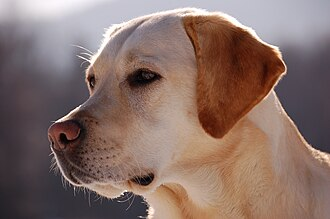

In [67]:
from PIL import Image

# 1) 먼저 원본을 열어서 파일 포맷(JPEG/PNG/...) 정보를 확인
_raw = Image.open("sample_images/dog.jpg")
print(f"포맷: {_raw.format}")           # 'JPEG' — Image.open 직후에만 보존됨

# 2) PNG(RGBA) 등 다양한 포맷에 안전하게 대응하기 위해 RGB로 변환
#    (convert는 새 이미지를 만들기 때문에 _raw.format 정보가 사라짐 → 위에서 미리 출력)
img = _raw.convert("RGB")

print(f"이미지 크기 (가로 × 세로): {img.size}")
print(f"모드 (채널): {img.mode}")

img

### 셀 [1-1] — (선택) 최신 휴대폰 사진 OOM 방지

본인 휴대폰 사진(예: `my_phone.jpg`)은 4032×3024 정도라서 그대로 다루면 메모리 폭증.
`thumbnail`은 비율을 유지하며 한 변이 800이 되도록 원본을 in-place 축소합니다.

In [68]:
# my_phone.jpg 가 없으면 dog.jpg 로 대체
import os
phone_path = "sample_images/my_phone.jpg" if os.path.exists("sample_images/my_phone.jpg") else "sample_images/dog.jpg"

phone = Image.open(phone_path).convert("RGB")
print(f"축소 전 크기: {phone.size}")
phone.thumbnail((800, 800))
print(f"축소 후 크기: {phone.size}")

축소 전 크기: (330, 219)
축소 후 크기: (330, 219)


## 셀 [2] — NumPy 배열로 변환

이미지를 진짜 숫자 배열로 들여다봅니다. `shape = (H, W, 3)`, `dtype = uint8`, 값 범위 `0~255`.

In [69]:
import numpy as np

arr = np.array(img)
print(f"shape: {arr.shape}")
print(f"dtype: {arr.dtype}")
print(f"최솟값: {arr.min()},  최댓값: {arr.max()}")

print("\n왼쪽 위 3×3 픽셀의 RGB 값:")
print(arr[:3, :3])

shape: (219, 330, 3)
dtype: uint8
최솟값: 0,  최댓값: 255

왼쪽 위 3×3 픽셀의 RGB 값:
[[[219 212 219]
  [218 211 218]
  [216 209 216]]

 [[218 211 218]
  [216 209 216]
  [214 207 214]]

 [[217 210 217]
  [215 208 215]
  [213 206 213]]]


## 셀 [3] — RGB 채널 분리해서 시각화

원본 / R / G / B 채널을 나란히 표시. 잎사귀는 G, 하늘은 B에서 밝게 나타납니다.

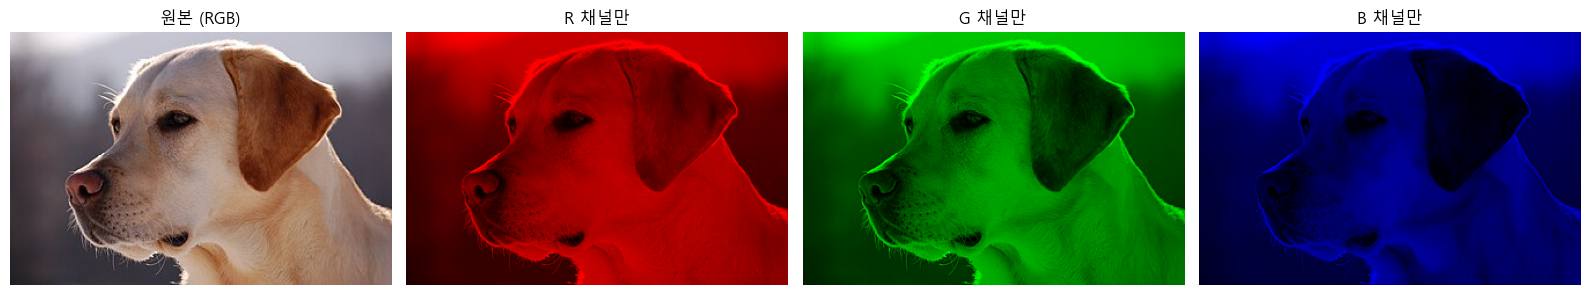

In [70]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(arr)
axes[0].set_title("원본 (RGB)")
axes[0].axis("off")

r_only = np.zeros_like(arr); r_only[:, :, 0] = arr[:, :, 0]
axes[1].imshow(r_only); axes[1].set_title("R 채널만"); axes[1].axis("off")

g_only = np.zeros_like(arr); g_only[:, :, 1] = arr[:, :, 1]
axes[2].imshow(g_only); axes[2].set_title("G 채널만"); axes[2].axis("off")

b_only = np.zeros_like(arr); b_only[:, :, 2] = arr[:, :, 2]
axes[3].imshow(b_only); axes[3].set_title("B 채널만"); axes[3].axis("off")

plt.tight_layout(); plt.show()

## 셀 [4] — `ToTensor()` 변환 (HWC → CHW, 0~255 → 0~1, uint8 → float32)

`ToTensor` 한 줄이 자동으로 해주는 3가지를 직접 확인합니다.

In [71]:
import torch
from torchvision import transforms

to_tensor = transforms.ToTensor()
tensor = to_tensor(img)

print(f"shape:   {tensor.shape}")
print(f"dtype:   {tensor.dtype}")
print(f"최솟값:   {tensor.min():.4f}")
print(f"최댓값:   {tensor.max():.4f}")

AttributeError: module 'torch.library' has no attribute 'register_fake'

## 셀 [5] — Resize (224×224 단독)

모델 입력 크기 통일. 단독 Resize는 종횡비를 깨뜨릴 수 있다는 점을 다음 셀에서 보강.

In [72]:
resize = transforms.Resize((224, 224))
resized_img = resize(img)

print(f"리사이즈 전: {img.size}")
print(f"리사이즈 후: {resized_img.size}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img); axes[0].set_title("원본"); axes[0].axis("off")
axes[1].imshow(resized_img); axes[1].set_title("224×224 리사이즈"); axes[1].axis("off")
plt.show()

NameError: name 'transforms' is not defined

### 셀 [5-1] — 실무 표준: `Resize(256) → CenterCrop(224)`

비율을 보존하면서 224×224 정사각형을 얻는 방법. ViT의 `ImageProcessor` 기본 동작.

In [73]:
preprocess_v2 = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

out = preprocess_v2(img)
print(f"shape: {out.shape}")

NameError: name 'transforms' is not defined

## 셀 [6] — 표준 전처리 파이프라인 (Resize → ToTensor → Normalize)

거의 모든 이미지 분류의 표준. ImageNet 평균/표준편차 사용.

In [74]:
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

x = preprocess(img)
print(f"shape: {x.shape}")
print(f"평균: {x.mean():.4f}, 표준편차: {x.std():.4f}")
print(f"최솟값: {x.min():.4f}, 최댓값: {x.max():.4f}")

NameError: name 'transforms' is not defined

## 셀 [7] — HuggingFace `datasets`로 CIFAR-10 로드

한 줄 다운로드 + 자동 캐싱. 최초 1회만 약 170MB 다운로드.

In [75]:
from datasets import load_dataset

ds = load_dataset("uoft-cs/cifar10")
print(ds)

c:\Users\myoungjin\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\myoungjin\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\myoungjin\.cache\huggingface\hub\datasets--uoft-cs--cifar10. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python 

DatasetDict({
    train: Dataset({
        features: ['img', 'label'],
        num_rows: 50000
    })
    test: Dataset({
        features: ['img', 'label'],
        num_rows: 10000
    })
})


## 셀 [8] — 데이터 한 개 꺼내보기

In [76]:
sample = ds["train"][0]
print(sample)

label_names = ds["train"].features["label"].names
print(f"\n라벨 종류: {label_names}")
print(f"이 이미지의 라벨: {label_names[sample['label']]}")

{'img': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=32x32 at 0x203F8EE5160>, 'label': 0}

라벨 종류: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
이 이미지의 라벨: airplane


## 셀 [9] — 무작위 9장 시각화 (정답 맞히기 게임)

32×32에서 사람도 헷갈리는 사진이 많다는 사실을 발견.

NameError: name 'ds' is not defined

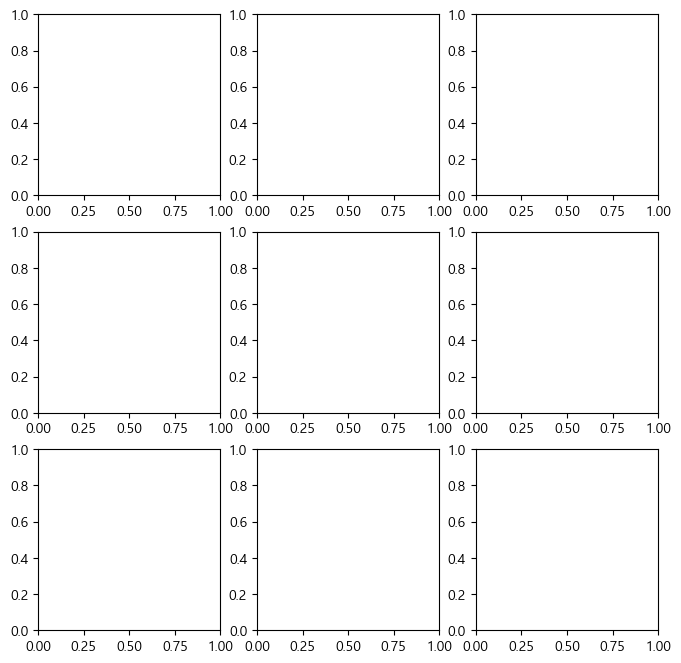

In [57]:
import random

fig, axes = plt.subplots(3, 3, figsize=(8, 8))
random_indices = random.sample(range(len(ds["train"])), 9)

for ax, idx in zip(axes.flat, random_indices):
    item = ds["train"][idx]
    ax.imshow(item["img"])
    ax.set_title(label_names[item["label"]])
    ax.axis("off")
plt.tight_layout(); plt.show()

## 셀 [10] — CIFAR-10에 전처리 파이프라인 적용

`with_transform`은 데이터를 꺼낼 때마다 함수를 실행 (lazy).

In [ ]:
def transform_batch(batch):
    batch["pixel_values"] = [preprocess(img.convert("RGB")) for img in batch["img"]]
    return batch

ds_processed = ds.with_transform(transform_batch)

first = ds_processed["train"][0]
print(f"pixel_values shape: {first['pixel_values'].shape}")
print(f"label: {label_names[first['label']]}")

## 셀 [11] — 정규화 전/후 비교 (denormalize)

정규화된 텐서를 그대로 imshow하면 색이 이상하게 보입니다. 원본 복원 함수로 비교.

In [ ]:
def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)

x = first["pixel_values"]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(x.permute(1, 2, 0))
axes[0].set_title("정규화된 상태\n(사람 눈에 이상함)")
axes[0].axis("off")

axes[1].imshow(denormalize(x).permute(1, 2, 0))
axes[1].set_title("역정규화\n(원본 복원)")
axes[1].axis("off")
plt.show()

## 셀 [12] — DataLoader로 배치 처리

32장씩 묶어서 모델에 한 번에 입력. 최종 형태: `(B, C, H, W) = (32, 3, 224, 224)`.

In [58]:
from torch.utils.data import DataLoader

def collate_fn(batch):
    pixel_values = torch.stack([item["pixel_values"] for item in batch])
    labels = torch.tensor([item["label"] for item in batch])
    return {"pixel_values": pixel_values, "labels": labels}

loader = DataLoader(
    ds_processed["train"],
    batch_size=32, shuffle=True,
    collate_fn=collate_fn,
)

batch = next(iter(loader))
print(f"pixel_values shape: {batch['pixel_values'].shape}")
print(f"labels shape:        {batch['labels'].shape}")

NameError: name 'ds_processed' is not defined

---
## 1교시 마무리 체크리스트

- [ ] 셀 [4]에서 `tensor.shape`가 `(3, H, W)`로 바뀐 것을 확인했다.
- [ ] 셀 [6]에서 정규화 후 평균이 0 근처, 표준편차가 1 근처가 됐다.
- [ ] 셀 [10]에서 CIFAR-10 한 장의 `pixel_values.shape`가 `(3, 224, 224)`다.
- [ ] 셀 [12]에서 배치 텐서의 shape가 `(32, 3, 224, 224)`다.

**다음 시간(2교시) 예고**: 같은 사진을 매번 다르게 변형해서 학습 데이터를 부풀리는 **데이터 증강(Augmentation)** 기법을 다룹니다.